<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/PipeNetworkOptim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dry-gas parallel-pipeline network optimization with NeqSim

This notebook develops a reproducible engineering workflow for allocating dry sales gas
between two parallel transmission branches. It combines NeqSim thermodynamics and process
equipment with pressure balancing, capacity screening, compressor sizing, and constrained
diameter selection.

**Intended audience:** process, pipeline, and flow-assurance engineers; graduate students;
and Python users who know basic steady-state process simulation.

## Prerequisites and learning objectives

You should be comfortable with pressure, mass flow, pipe diameter, and steady-state mass
balance. No local NeqSim checkout or private input is required.

After completing the notebook, you can:

1. construct a dry natural-gas model and inspect its NeqSim properties;
2. configure `AdiabaticPipe` for fixed-flow pressure prediction and fixed-pressure capacity;
3. balance two unequal parallel branches by matching their delivery pressures;
4. screen throughput and diameter scenarios without reusing mutable process state;
5. connect `Compressor`, `Cooler`, `Splitter`, pipes, and `Mixer` in a `ProcessSystem`;
6. verify pressure, velocity, mass, component, and compressor-energy results; and
7. distinguish an educational screening optimization from detailed pipeline design.

## 1. Colab-compatible setup

The cell installs the latest public PyPI release only when `neqsim` is absent. Colab
normally provides NumPy, pandas, Matplotlib, and SciPy. The notebook records the actual
versions used for the calculation.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

In [2]:
import importlib.metadata
import math
import platform

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import jpype
import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.thermo import TPflash, fluid

NEQSIM_VERSION = importlib.metadata.version("neqsim")
PYTHON_VERSION = platform.python_version()

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "grey": "#5F6368",
}

print(f"NeqSim version: {NEQSIM_VERSION}")
print(f"Python version: {PYTHON_VERSION}")
java_system = jpype.JClass("java.lang.System")
print(f"Java version: {java_system.getProperty('java.version')}")

NeqSim version: 3.16.0
Python version: 3.12.13
Java version: 17.0.19


## 2. Engineering problem and design basis

A compressor station receives dry sales gas at 80 bara and 25 °C. After compression and
cooling to 25 °C, a splitter sends the gas through two unequal horizontal branches. The
branches rejoin at a delivery hub that requires at least 100 bara.

- West branch: 95 km.
- East branch: 130 km.
- Commercial diameter options: 0.50–0.70 m.
- Pipe-wall roughness: 15 µm.
- Target flow for the final design: 300 kg/s.
- Maximum cooled header pressure: 145 bara.
- Compressor isentropic efficiency: 78%.

This is a **screening case**, not a code-compliant pipeline design. Wall thickness,
fracture control, terrain, heat transfer, line pack, availability, valves, transients,
surge, commercial cost, and environmental constraints require separate studies.

In [3]:
COMPOSITION_MOLE_FRACTION = {
    "nitrogen": 0.010,
    "CO2": 0.015,
    "methane": 0.915,
    "ethane": 0.045,
    "propane": 0.012,
    "i-butane": 0.003,
}

BRANCH_SPECS = pd.DataFrame(
    [
        {
            "branch": "West",
            "length_km": 95.0,
            "base_diameter_m": 0.55,
            "roughness_m": 15.0e-6,
        },
        {
            "branch": "East",
            "length_km": 130.0,
            "base_diameter_m": 0.65,
            "roughness_m": 15.0e-6,
        },
    ]
)

SUPPLY_PRESSURE_BARA = 80.0
SUPPLY_TEMPERATURE_C = 25.0
COOLED_HEADER_TEMPERATURE_C = 25.0
DELIVERY_PRESSURE_BARA = 100.0
TARGET_FLOW_KG_S = 300.0
MAXIMUM_HEADER_PRESSURE_BARA = 145.0
COMPRESSOR_EFFICIENCY = 0.78

display(BRANCH_SPECS)

,branch,length_km,base_diameter_m,roughness_m
0,West,95.0,0.55,0.000015
1,East,130.0,0.65,0.000015


The gas composition sums to one mole fraction. It is synthetic but representative of a
lean export gas. The two routes are intentionally unequal, so a 50/50 split is not
hydraulically balanced.

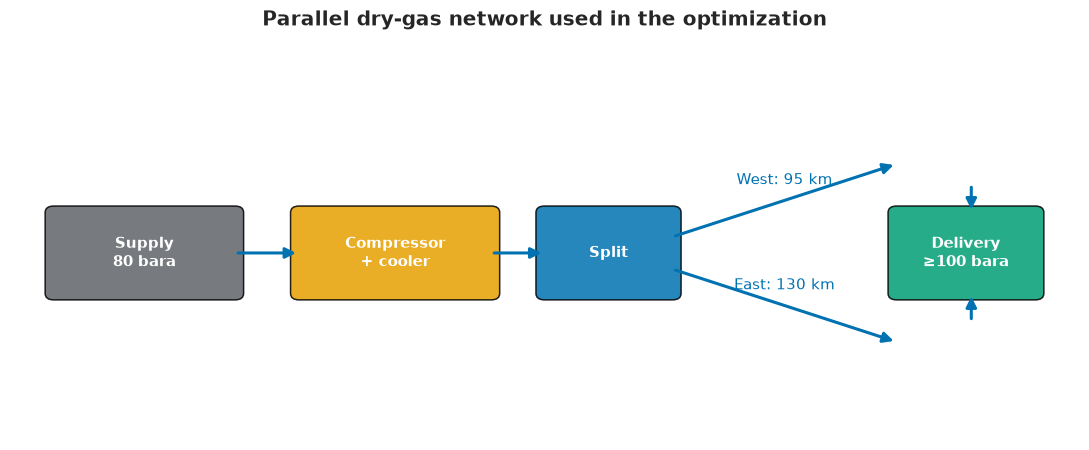

In [4]:
fig, ax = plt.subplots(figsize=(10.0, 4.2))
ax.set_xlim(0.0, 10.0)
ax.set_ylim(0.0, 5.0)
ax.axis("off")

boxes = [
    (0.4, 1.8, 1.7, 1.0, "Supply\n80 bara", COLORS["grey"]),
    (2.7, 1.8, 1.8, 1.0, "Compressor\n+ cooler", COLORS["orange"]),
    (5.0, 1.8, 1.2, 1.0, "Split", COLORS["blue"]),
    (8.3, 1.8, 1.3, 1.0, "Delivery\n≥100 bara", COLORS["green"]),
]

for x_position, y_position, width, height, label, color in boxes:
    patch = FancyBboxPatch(
        (x_position, y_position),
        width,
        height,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="black",
        alpha=0.85,
    )
    ax.add_patch(patch)
    ax.text(
        x_position + width / 2.0,
        y_position + height / 2.0,
        label,
        color="white",
        ha="center",
        va="center",
        fontsize=10,
        weight="bold",
    )

arrow_specs = [
    ((2.1, 2.3), (2.7, 2.3), ""),
    ((4.5, 2.3), (5.0, 2.3), ""),
    ((6.2, 2.5), (8.3, 3.4), "West: 95 km"),
    ((6.2, 2.1), (8.3, 1.2), "East: 130 km"),
    ((9.0, 3.15), (9.0, 2.8), ""),
    ((9.0, 1.45), (9.0, 1.8), ""),
]

for start, end, label in arrow_specs:
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=2.0,
        color=COLORS["blue"],
    )
    ax.add_patch(arrow)

    if label:
        label_x = 0.5 * (start[0] + end[0])
        label_y = 0.5 * (start[1] + end[1])
        ax.text(
            label_x,
            label_y + 0.25,
            label,
            ha="center",
            va="center",
            color=COLORS["blue"],
            fontsize=10,
        )

ax.set_title(
    "Parallel dry-gas network used in the optimization",
    fontsize=13,
    weight="bold",
)
fig.tight_layout()

## 3. Governing relationships

`AdiabaticPipe` evaluates a steady, one-dimensional algebraic pressure drop using the
NeqSim fluid density, viscosity, compressibility, and friction factor. For a horizontal
compressible-gas line, the pressure-squared form motivates the expected trend:

$$
p_1^2 - p_2^2 \propto \frac{f L \dot m^2}{D^5}
$$

Here $p_1$ and $p_2$ are absolute inlet and outlet pressure in Pa, $f$ is the Darcy
friction factor, $L$ is length in m, $\dot m$ is mass flow in kg/s, and $D$ is internal
diameter in m. NeqSim recalculates properties rather than treating the proportionality as
an exact constant-property equation.

At the splitter and mixer, steady mass conservation requires:

$$
\dot m_{total} = \dot m_W + \dot m_E
$$

A physically balanced parallel network also requires the same pressure at the common
downstream node:

$$
p_{W,out} = p_{E,out}
$$

The compressor power check uses the steady enthalpy rise:

$$
\dot W = \dot H_{out} - \dot H_{in}
$$

$\dot W$ is in kW when the enthalpy-flow difference is converted from W to kW.

### Model choice and validity limits

SRK is selected because this is a lean hydrocarbon gas far from liquid dropout. The
notebook nevertheless flashes the fluid and checks that it remains gas at all design
endpoints. `AdiabaticPipe` is appropriate for rapid single-phase screening and can solve
pressure from flow or flow from specified outlet pressure. It does not provide distributed
thermal profiles, line pack, terrain-dependent multiphase behavior, or transient waves.

A detailed project should compare a thermal pipeline model, inspect the phase envelope,
include fittings and valves, use surveyed elevations, and calibrate roughness and heat
transfer against operating data.

In [5]:
def build_sales_gas(
    pressure_bara,
    temperature_c,
    flow_kg_s,
):
    gas = fluid("srk")

    for component_name, mole_fraction in COMPOSITION_MOLE_FRACTION.items():
        gas.addComponent(component_name, mole_fraction)

    gas.setMixingRule("classic")
    gas.setPressure(pressure_bara, "bara")
    gas.setTemperature(temperature_c, "C")
    gas.setTotalFlowRate(flow_kg_s, "kg/sec")
    TPflash(gas)
    gas.initProperties()
    return gas

In [6]:
reference_gas = build_sales_gas(
    pressure_bara=135.0,
    temperature_c=COOLED_HEADER_TEMPERATURE_C,
    flow_kg_s=TARGET_FLOW_KG_S,
)

reference_summary = pd.DataFrame(
    {
        "quantity": [
            "Composition sum",
            "Number of phases",
            "Density",
            "Dynamic viscosity",
            "Molar mass",
        ],
        "value": [
            sum(COMPOSITION_MOLE_FRACTION.values()),
            reference_gas.getNumberOfPhases(),
            reference_gas.getDensity("kg/m3"),
            reference_gas.getViscosity("kg/msec"),
            reference_gas.getMolarMass() * 1000.0,
        ],
        "unit": [
            "mole fraction",
            "-",
            "kg/m³",
            "Pa·s",
            "kg/kmol",
        ],
    }
)

display(reference_summary.round(8))

,quantity,value,unit
0,Composition sum,1.000000,mole fraction
1,Number of phases,1.000000,-
2,Density,118.984674,kg/m³
3,Dynamic viscosity,0.000016,Pa·s
4,Molar mass,17.676313,kg/kmol


The reference state is a single gas phase. Density and viscosity are initialized explicitly
before reporting them. Pipeline equipment also initializes the properties it consumes;
unnecessary outlet-property initialization is avoided to preserve NeqSim's lazy-property
performance pattern.

## 4. Reusable NeqSim pipe calculation

Each call creates an independent fluid, stream, and pipe. This prevents an optimization
trial from mutating the next trial. With no specified outlet pressure, the pipe predicts
pressure for a fixed flow. When `outlet_pressure_bara` is supplied, NeqSim solves the
corresponding capacity.

In [7]:
def run_adiabatic_pipe(
    name,
    flow_kg_s,
    length_km,
    diameter_m,
    roughness_m,
    inlet_pressure_bara,
    temperature_c=COOLED_HEADER_TEMPERATURE_C,
    outlet_pressure_bara=None,
):
    gas = build_sales_gas(
        pressure_bara=inlet_pressure_bara,
        temperature_c=temperature_c,
        flow_kg_s=flow_kg_s,
    )
    inlet = jneqsim.process.equipment.stream.Stream(
        f"{name} inlet",
        gas,
    )
    inlet.run()

    pipe = jneqsim.process.equipment.pipeline.AdiabaticPipe(
        name,
        inlet,
    )
    pipe.setLength(length_km * 1000.0)
    pipe.setDiameter(diameter_m)
    pipe.setPipeWallRoughness(roughness_m)
    pipe.setInletElevation(0.0)
    pipe.setOutletElevation(0.0)

    if outlet_pressure_bara is not None:
        pipe.setOutletPressure(outlet_pressure_bara)

    pipe.run()
    outlet = pipe.getOutletStream()

    return {
        "pipe": pipe,
        "inlet": inlet,
        "outlet": outlet,
        "flow_kg_s": inlet.getFlowRate("kg/sec"),
        "outlet_pressure_bara": outlet.getPressure("bara"),
        "velocity_m_s": pipe.getVelocity(),
        "reynolds_number": pipe.getReynoldsNumber(),
        "friction_factor": pipe.getFrictionFactor(),
    }

In [8]:
base_pipe = run_adiabatic_pipe(
    name="West base case",
    flow_kg_s=100.0,
    length_km=95.0,
    diameter_m=0.55,
    roughness_m=15.0e-6,
    inlet_pressure_bara=145.0,
)

base_pipe_summary = pd.DataFrame(
    {
        "quantity": [
            "Mass flow",
            "Inlet pressure",
            "Outlet pressure",
            "Pressure drop",
            "Gas velocity",
            "Reynolds number",
            "Darcy friction factor",
        ],
        "value": [
            base_pipe["flow_kg_s"],
            base_pipe["inlet"].getPressure("bara"),
            base_pipe["outlet_pressure_bara"],
            145.0 - base_pipe["outlet_pressure_bara"],
            base_pipe["velocity_m_s"],
            base_pipe["reynolds_number"],
            base_pipe["friction_factor"],
        ],
        "unit": [
            "kg/s",
            "bara",
            "bara",
            "bar",
            "m/s",
            "-",
            "-",
        ],
    }
)

display(base_pipe_summary.round(6))

,quantity,value,unit
0,Mass flow,1.000000e+02,kg/s
1,Inlet pressure,1.450000e+02,bara
2,Outlet pressure,1.326238e+02,bara
3,Pressure drop,1.237624e+01,bar
4,Gas velocity,3.625908e+00,m/s
5,Reynolds number,1.437313e+07,-
6,Darcy friction factor,9.828000e-03,-


The positive pressure drop, turbulent Reynolds number, and moderate gas velocity are
consistent with a long transmission line. The friction factor is a calculated result, not
a fitted notebook constant.

## 5. Capacity mode and diameter sensitivity

Capacity mode answers a useful planning question: how much gas can a branch carry between
specified absolute pressures? The screen holds inlet pressure, delivery pressure, length,
temperature, and roughness constant while varying only diameter.

In [9]:
diameter_options_m = np.arange(0.50, 0.751, 0.05)
capacity_records = []

for _, branch in BRANCH_SPECS.iterrows():
    for diameter_m in diameter_options_m:
        result = run_adiabatic_pipe(
            name=f"{branch['branch']} capacity",
            flow_kg_s=50.0,
            length_km=branch["length_km"],
            diameter_m=diameter_m,
            roughness_m=branch["roughness_m"],
            inlet_pressure_bara=145.0,
            outlet_pressure_bara=DELIVERY_PRESSURE_BARA,
        )
        capacity_records.append(
            {
                "branch": branch["branch"],
                "diameter (m)": diameter_m,
                "capacity (kg/s)": result["flow_kg_s"],
                "velocity (m/s)": result["velocity_m_s"],
            }
        )

capacity_table = pd.DataFrame(capacity_records)
display(capacity_table.round(5))

,branch,diameter (m),capacity (kg/s),velocity (m/s)
0,West,0.50,141.11609,5.64199
1,West,0.55,180.63596,5.96863
2,West,0.60,226.29743,6.28308
3,West,0.65,278.36753,6.58548
4,West,0.70,337.26587,6.87974
5,West,0.75,403.18318,7.16433
6,East,0.50,120.44064,4.81536
7,East,0.55,154.16223,5.09387
8,East,0.60,193.14804,5.36270
9,East,0.65,237.62697,5.62166


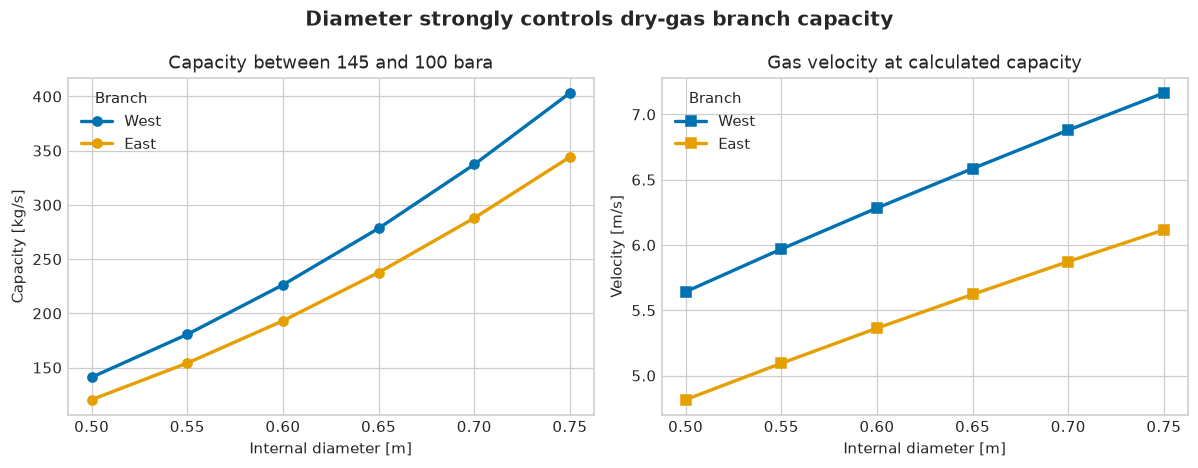

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3))

for branch_name, color in [
    ("West", COLORS["blue"]),
    ("East", COLORS["orange"]),
]:
    branch_data = capacity_table[
        capacity_table["branch"] == branch_name
    ]
    axes[0].plot(
        branch_data["diameter (m)"],
        branch_data["capacity (kg/s)"],
        marker="o",
        linewidth=2.2,
        label=branch_name,
        color=color,
    )
    axes[1].plot(
        branch_data["diameter (m)"],
        branch_data["velocity (m/s)"],
        marker="s",
        linewidth=2.2,
        label=branch_name,
        color=color,
    )

axes[0].set_title("Capacity between 145 and 100 bara")
axes[0].set_xlabel("Internal diameter [m]")
axes[0].set_ylabel("Capacity [kg/s]")
axes[0].legend(title="Branch")

axes[1].set_title("Gas velocity at calculated capacity")
axes[1].set_xlabel("Internal diameter [m]")
axes[1].set_ylabel("Velocity [m/s]")
axes[1].legend(title="Branch")

fig.suptitle(
    "Diameter strongly controls dry-gas branch capacity",
    fontsize=13,
    weight="bold",
)
fig.tight_layout()

Capacity increases steeply with diameter, as expected from the pressure-squared relation.
At equal diameter the shorter west route carries more gas. Capacity mode is valuable for
rapid screening, but the selected network is later reconciled in fixed-flow mode because
that is the actual final operating specification.

## 6. Pressure-balanced parallel-flow allocation

For a fixed total flow and header pressure, the branch split is found by bisection. A trial
is balanced when west and east outlet pressures match. The search uses fresh NeqSim objects
for every evaluation and checks that the mismatch changes sign across the bracket.

In [11]:
def evaluate_parallel_split(
    total_flow_kg_s,
    header_pressure_bara,
    west_fraction,
    west_diameter_m,
    east_diameter_m,
):
    west_spec = BRANCH_SPECS.iloc[0]
    east_spec = BRANCH_SPECS.iloc[1]
    west_result = run_adiabatic_pipe(
        name="West split trial",
        flow_kg_s=total_flow_kg_s * west_fraction,
        length_km=west_spec["length_km"],
        diameter_m=west_diameter_m,
        roughness_m=west_spec["roughness_m"],
        inlet_pressure_bara=header_pressure_bara,
    )
    east_result = run_adiabatic_pipe(
        name="East split trial",
        flow_kg_s=total_flow_kg_s * (1.0 - west_fraction),
        length_km=east_spec["length_km"],
        diameter_m=east_diameter_m,
        roughness_m=east_spec["roughness_m"],
        inlet_pressure_bara=header_pressure_bara,
    )
    mismatch_bar = (
        west_result["outlet_pressure_bara"]
        - east_result["outlet_pressure_bara"]
    )
    return mismatch_bar, west_result, east_result

In [12]:
def solve_balanced_split(
    total_flow_kg_s,
    header_pressure_bara,
    west_diameter_m,
    east_diameter_m,
    lower_fraction=0.30,
    upper_fraction=0.60,
    iterations=26,
):
    for _ in range(iterations):
        west_fraction = 0.5 * (
            lower_fraction + upper_fraction
        )
        mismatch_bar, west_result, east_result = (
            evaluate_parallel_split(
                total_flow_kg_s,
                header_pressure_bara,
                west_fraction,
                west_diameter_m,
                east_diameter_m,
            )
        )

        if mismatch_bar > 0.0:
            lower_fraction = west_fraction
        else:
            upper_fraction = west_fraction

    assert abs(mismatch_bar) < 1.0e-5
    return {
        "west_fraction": west_fraction,
        "mismatch_bar": mismatch_bar,
        "west": west_result,
        "east": east_result,
    }

In [13]:
split_scan_records = []
split_scan_fractions = np.linspace(0.20, 0.80, 25)

for west_fraction in split_scan_fractions:
    mismatch_bar, west_result, east_result = evaluate_parallel_split(
        total_flow_kg_s=120.0,
        header_pressure_bara=145.0,
        west_fraction=west_fraction,
        west_diameter_m=0.55,
        east_diameter_m=0.65,
    )
    split_scan_records.append(
        {
            "west fraction (-)": west_fraction,
            "west outlet (bara)": west_result[
                "outlet_pressure_bara"
            ],
            "east outlet (bara)": east_result[
                "outlet_pressure_bara"
            ],
            "pressure mismatch (bar)": mismatch_bar,
        }
    )

split_scan_table = pd.DataFrame(split_scan_records)
balanced_base = solve_balanced_split(
    total_flow_kg_s=120.0,
    header_pressure_bara=145.0,
    west_diameter_m=0.55,
    east_diameter_m=0.65,
)

balanced_base_summary = pd.DataFrame(
    {
        "quantity": [
            "West flow fraction",
            "West mass flow",
            "East mass flow",
            "West outlet pressure",
            "East outlet pressure",
            "Absolute pressure mismatch",
        ],
        "value": [
            balanced_base["west_fraction"],
            balanced_base["west"]["flow_kg_s"],
            balanced_base["east"]["flow_kg_s"],
            balanced_base["west"]["outlet_pressure_bara"],
            balanced_base["east"]["outlet_pressure_bara"],
            abs(balanced_base["mismatch_bar"]),
        ],
        "unit": [
            "-",
            "kg/s",
            "kg/s",
            "bara",
            "bara",
            "bar",
        ],
    }
)

display(balanced_base_summary.round(8))

,quantity,value,unit
0,West flow fraction,4.321132e-01,-
1,West mass flow,5.185358e+01,kg/s
2,East mass flow,6.814642e+01,kg/s
3,West outlet pressure,1.416984e+02,bara
4,East outlet pressure,1.416984e+02,bara
5,Absolute pressure mismatch,1.200000e-07,bar


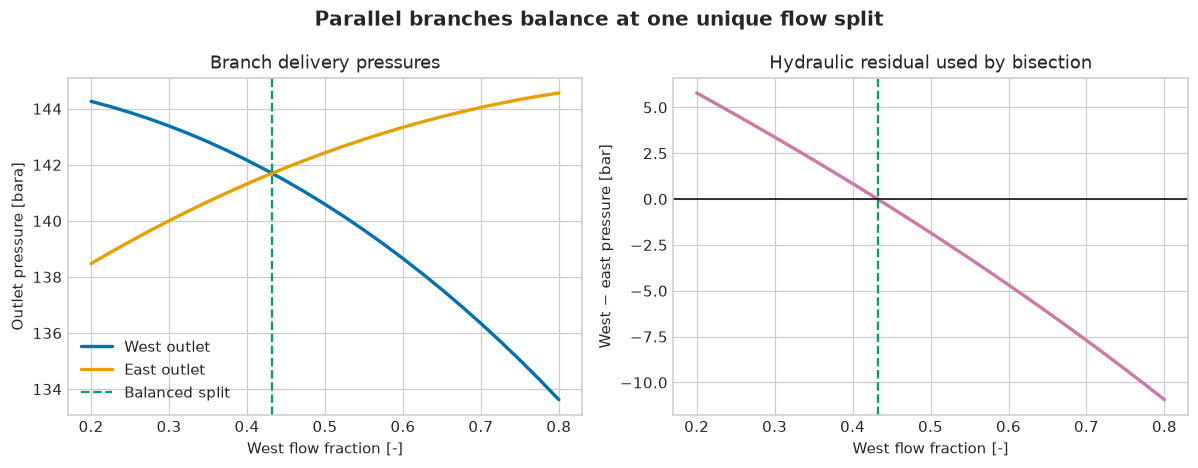

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3))

axes[0].plot(
    split_scan_table["west fraction (-)"],
    split_scan_table["west outlet (bara)"],
    label="West outlet",
    color=COLORS["blue"],
    linewidth=2.2,
)
axes[0].plot(
    split_scan_table["west fraction (-)"],
    split_scan_table["east outlet (bara)"],
    label="East outlet",
    color=COLORS["orange"],
    linewidth=2.2,
)
axes[0].axvline(
    balanced_base["west_fraction"],
    color=COLORS["green"],
    linestyle="--",
    label="Balanced split",
)
axes[0].set_title("Branch delivery pressures")
axes[0].set_xlabel("West flow fraction [-]")
axes[0].set_ylabel("Outlet pressure [bara]")
axes[0].legend()

axes[1].plot(
    split_scan_table["west fraction (-)"],
    split_scan_table["pressure mismatch (bar)"],
    color=COLORS["purple"],
    linewidth=2.2,
)
axes[1].axhline(0.0, color="black", linewidth=1.0)
axes[1].axvline(
    balanced_base["west_fraction"],
    color=COLORS["green"],
    linestyle="--",
)
axes[1].set_title("Hydraulic residual used by bisection")
axes[1].set_xlabel("West flow fraction [-]")
axes[1].set_ylabel("West − east pressure [bar]")

fig.suptitle(
    "Parallel branches balance at one unique flow split",
    fontsize=13,
    weight="bold",
)
fig.tight_layout()

Sending more gas west increases the west pressure drop and reduces the east pressure drop.
The monotonic residual gives a well-conditioned one-dimensional root. A fixed 50/50 split
would leave unequal downstream pressures and is therefore not a valid representation of
two branches connected to the same node.

## 7. Throughput operating envelope

The next screen holds geometry and header pressure fixed while increasing total flow. Each
scenario is solved independently. The result shows the remaining margin above the
100 bara delivery requirement and how the balanced split changes with throughput.

In [15]:
throughput_records = []

for total_flow_kg_s in np.arange(100.0, 321.0, 20.0):
    balanced_case = solve_balanced_split(
        total_flow_kg_s=total_flow_kg_s,
        header_pressure_bara=145.0,
        west_diameter_m=0.55,
        east_diameter_m=0.65,
    )
    delivery_pressure_bara = min(
        balanced_case["west"]["outlet_pressure_bara"],
        balanced_case["east"]["outlet_pressure_bara"],
    )
    throughput_records.append(
        {
            "total flow (kg/s)": total_flow_kg_s,
            "west fraction (-)": balanced_case["west_fraction"],
            "delivery pressure (bara)": delivery_pressure_bara,
            "west velocity (m/s)": balanced_case["west"][
                "velocity_m_s"
            ],
            "east velocity (m/s)": balanced_case["east"][
                "velocity_m_s"
            ],
        }
    )

throughput_table = pd.DataFrame(throughput_records)
display(throughput_table.round(5))

,total flow (kg/s),west fraction (-),delivery pressure (bara),west velocity (m/s),east velocity (m/s)
0,100.0,0.43216,142.69208,1.45168,1.36566
1,120.0,0.43211,141.69845,1.75440,1.65079
2,140.0,0.43207,140.52133,2.06434,1.94275
3,160.0,0.43204,139.15576,2.38307,2.24302
4,180.0,0.43201,137.59556,2.71241,2.55329
5,200.0,0.43199,135.83316,3.05472,2.87580
6,220.0,0.43197,133.85933,3.41219,3.21260
7,240.0,0.43195,131.66281,3.78796,3.56666
8,260.0,0.43193,129.22979,4.18572,3.94144
9,280.0,0.43192,126.54328,4.61005,4.34125


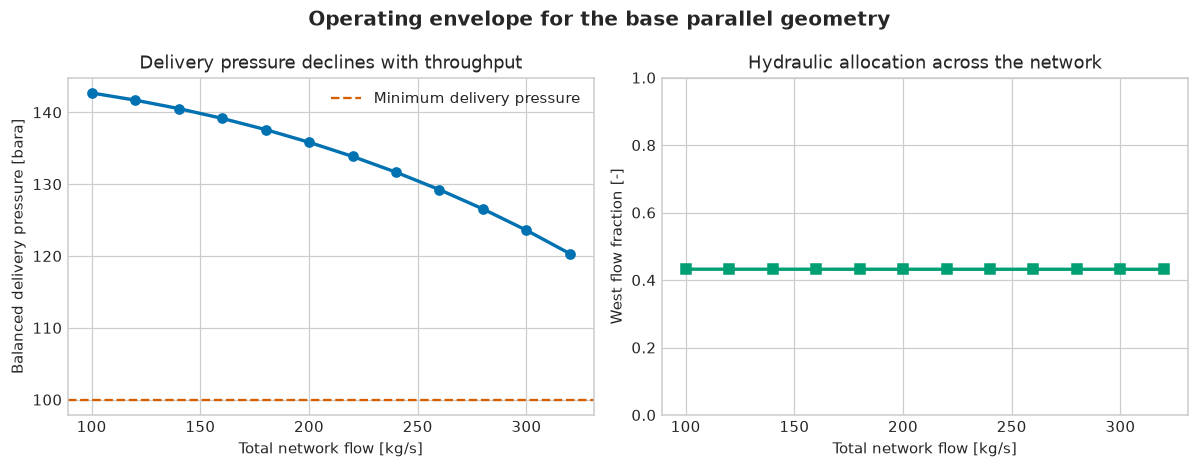

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3))

axes[0].plot(
    throughput_table["total flow (kg/s)"],
    throughput_table["delivery pressure (bara)"],
    marker="o",
    color=COLORS["blue"],
    linewidth=2.2,
)
axes[0].axhline(
    DELIVERY_PRESSURE_BARA,
    color=COLORS["red"],
    linestyle="--",
    label="Minimum delivery pressure",
)
axes[0].set_title("Delivery pressure declines with throughput")
axes[0].set_xlabel("Total network flow [kg/s]")
axes[0].set_ylabel("Balanced delivery pressure [bara]")
axes[0].legend()

axes[1].plot(
    throughput_table["total flow (kg/s)"],
    throughput_table["west fraction (-)"],
    marker="s",
    color=COLORS["green"],
    linewidth=2.2,
)
axes[1].set_title("Hydraulic allocation across the network")
axes[1].set_xlabel("Total network flow [kg/s]")
axes[1].set_ylabel("West flow fraction [-]")
axes[1].set_ylim(0.0, 1.0)

fig.suptitle(
    "Operating envelope for the base parallel geometry",
    fontsize=13,
    weight="bold",
)
fig.tight_layout()

The pressure trend is smooth and monotonic. The balanced fraction changes only slightly
because both branches see the same fluid and their hydraulic resistance ratio is stable.
A project model should repeat this envelope for composition, temperature, roughness,
availability, and terrain cases.

## 8. Diameter screening and constrained selection

Each diameter pair is first screened in NeqSim capacity mode at exactly 100 bara delivery.
A bisection search finds the cooled header pressure whose two branch capacities sum to
300 kg/s. This fast screen is followed by a fixed-flow reconciliation of the selected pair.

The pipe-size index is:

$$
I_D = L_W D_W^2 + L_E D_E^2
$$

$I_D$ has units km·m² and is only a transparent geometry proxy. It is not CAPEX. The
screen minimizes this index subject to a conservative preliminary header-pressure guard
band of 140 bara; final fixed-flow validation must remain below the 145 bara design limit.

In [17]:
def solve_screening_header_pressure(
    total_flow_kg_s,
    delivery_pressure_bara,
    west_diameter_m,
    east_diameter_m,
    iterations=24,
):
    lower_bara = delivery_pressure_bara + 0.1
    upper_bara = 220.0
    west_spec = BRANCH_SPECS.iloc[0]
    east_spec = BRANCH_SPECS.iloc[1]

    for _ in range(iterations):
        trial_bara = 0.5 * (lower_bara + upper_bara)
        west_capacity = run_adiabatic_pipe(
            name="West capacity trial",
            flow_kg_s=50.0,
            length_km=west_spec["length_km"],
            diameter_m=west_diameter_m,
            roughness_m=west_spec["roughness_m"],
            inlet_pressure_bara=trial_bara,
            outlet_pressure_bara=delivery_pressure_bara,
        )
        east_capacity = run_adiabatic_pipe(
            name="East capacity trial",
            flow_kg_s=50.0,
            length_km=east_spec["length_km"],
            diameter_m=east_diameter_m,
            roughness_m=east_spec["roughness_m"],
            inlet_pressure_bara=trial_bara,
            outlet_pressure_bara=delivery_pressure_bara,
        )
        total_capacity_kg_s = (
            west_capacity["flow_kg_s"]
            + east_capacity["flow_kg_s"]
        )

        if total_capacity_kg_s < total_flow_kg_s:
            lower_bara = trial_bara
        else:
            upper_bara = trial_bara

    header_pressure_bara = 0.5 * (lower_bara + upper_bara)
    return {
        "header_pressure_bara": header_pressure_bara,
        "west_capacity": west_capacity,
        "east_capacity": east_capacity,
        "west_fraction": (
            west_capacity["flow_kg_s"] / total_flow_kg_s
        ),
    }

In [18]:
def compressor_power_kw(
    flow_kg_s,
    outlet_pressure_bara,
):
    compressor_gas = build_sales_gas(
        pressure_bara=SUPPLY_PRESSURE_BARA,
        temperature_c=SUPPLY_TEMPERATURE_C,
        flow_kg_s=flow_kg_s,
    )
    compressor_feed = jneqsim.process.equipment.stream.Stream(
        "Power-screen feed",
        compressor_gas,
    )
    compressor = jneqsim.process.equipment.compressor.Compressor(
        "Power-screen compressor",
        compressor_feed,
    )
    compressor.setOutletPressure(outlet_pressure_bara, "bara")
    compressor.setIsentropicEfficiency(COMPRESSOR_EFFICIENCY)
    compressor.run()
    return compressor.getPower("kW")

In [19]:
design_records = []

for west_diameter_m in np.arange(0.50, 0.701, 0.05):
    for east_diameter_m in np.arange(0.50, 0.701, 0.05):
        screen = solve_screening_header_pressure(
            total_flow_kg_s=TARGET_FLOW_KG_S,
            delivery_pressure_bara=DELIVERY_PRESSURE_BARA,
            west_diameter_m=west_diameter_m,
            east_diameter_m=east_diameter_m,
        )
        header_pressure_bara = screen["header_pressure_bara"]
        power_kw = compressor_power_kw(
            TARGET_FLOW_KG_S,
            header_pressure_bara,
        )
        pipe_size_index = (
            BRANCH_SPECS.iloc[0]["length_km"]
            * west_diameter_m**2
            + BRANCH_SPECS.iloc[1]["length_km"]
            * east_diameter_m**2
        )
        design_records.append(
            {
                "west diameter (m)": west_diameter_m,
                "east diameter (m)": east_diameter_m,
                "screen header (bara)": header_pressure_bara,
                "west fraction (-)": screen["west_fraction"],
                "compressor power (MW)": power_kw / 1000.0,
                "pipe size index (km m²)": pipe_size_index,
                "maximum velocity (m/s)": max(
                    screen["west_capacity"]["velocity_m_s"],
                    screen["east_capacity"]["velocity_m_s"],
                ),
            }
        )

design_table = pd.DataFrame(design_records)
screened_designs = design_table[
    design_table["screen header (bara)"] <= 140.0
].copy()
selected_screen_index = screened_designs[
    "pipe size index (km m²)"
].idxmin()
selected_screen = design_table.loc[selected_screen_index]

display(
    design_table.sort_values(
        [
            "pipe size index (km m²)",
            "screen header (bara)",
        ]
    ).round(5)
)

,west diameter (m),east diameter (m),screen header (bara),west fraction (-),compressor power (MW),pipe size index (km m²),maximum velocity (m/s)
0,0.50,0.50,156.43285,0.53950,34.81814,56.2500,5.99573
5,0.55,0.50,144.73590,0.59996,30.35309,61.2375,5.95830
1,0.50,0.55,146.19840,0.47789,30.92353,63.0750,5.68400
10,0.60,0.50,135.25011,0.65273,26.56108,66.7000,5.84399
6,0.55,0.55,137.41129,0.53956,27.43960,68.0625,5.65427
2,0.50,0.60,137.51418,0.42220,27.48120,70.5500,5.34929
15,0.65,0.50,127.69199,0.69812,23.41577,72.6375,5.66100
11,0.60,0.55,130.05569,0.59487,24.41202,73.5250,5.55139
7,0.55,0.60,130.99082,0.48323,24.80293,75.5375,5.32597
3,0.50,0.65,130.29328,0.37260,24.51151,78.6750,4.99741


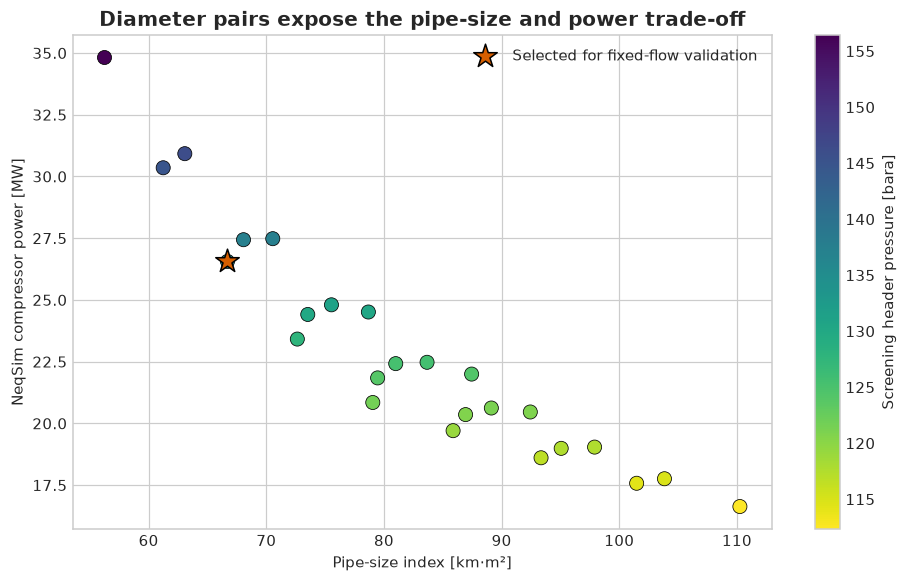

In [20]:
fig, ax = plt.subplots(figsize=(8.8, 5.4))
scatter = ax.scatter(
    design_table["pipe size index (km m²)"],
    design_table["compressor power (MW)"],
    c=design_table["screen header (bara)"],
    cmap="viridis_r",
    s=85,
    edgecolor="black",
    linewidth=0.5,
)
ax.scatter(
    selected_screen["pipe size index (km m²)"],
    selected_screen["compressor power (MW)"],
    marker="*",
    s=260,
    color=COLORS["red"],
    edgecolor="black",
    label="Selected for fixed-flow validation",
    zorder=4,
)
colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("Screening header pressure [bara]")
ax.set_xlabel("Pipe-size index [km·m²]")
ax.set_ylabel("NeqSim compressor power [MW]")
ax.set_title(
    "Diameter pairs expose the pipe-size and power trade-off",
    fontsize=13,
    weight="bold",
)
ax.legend()
fig.tight_layout()

Larger diameters reduce required pressure and compressor power, but increase the transparent
pipe-size proxy. The highlighted pair is not claimed to be an economic optimum. It is the
smallest screened geometry that respects the guard band and is therefore carried into the
rigorous fixed-flow calculation.

## 9. Fixed-flow reconciliation of the selected design

Capacity mode is excellent for screening, but the final network specification is fixed
total flow. The following nested bisection solves the branch split at each trial header
pressure and then solves the exact header pressure needed for 100 bara delivery.

In [21]:
def solve_exact_header_pressure(
    total_flow_kg_s,
    delivery_pressure_bara,
    west_diameter_m,
    east_diameter_m,
    lower_header_bara=134.0,
    upper_header_bara=180.0,
    iterations=24,
):
    for _ in range(iterations):
        trial_header_bara = 0.5 * (
            lower_header_bara + upper_header_bara
        )
        balanced_case = solve_balanced_split(
            total_flow_kg_s=total_flow_kg_s,
            header_pressure_bara=trial_header_bara,
            west_diameter_m=west_diameter_m,
            east_diameter_m=east_diameter_m,
            lower_fraction=0.40,
            upper_fraction=0.75,
            iterations=24,
        )
        delivery_bara = min(
            balanced_case["west"]["outlet_pressure_bara"],
            balanced_case["east"]["outlet_pressure_bara"],
        )

        if delivery_bara < delivery_pressure_bara:
            lower_header_bara = trial_header_bara
        else:
            upper_header_bara = trial_header_bara

    header_pressure_bara = 0.5 * (
        lower_header_bara + upper_header_bara
    )
    balanced_case = solve_balanced_split(
        total_flow_kg_s=total_flow_kg_s,
        header_pressure_bara=header_pressure_bara,
        west_diameter_m=west_diameter_m,
        east_diameter_m=east_diameter_m,
        lower_fraction=0.40,
        upper_fraction=0.75,
        iterations=26,
    )
    return header_pressure_bara, balanced_case

In [22]:
selected_west_diameter_m = float(
    selected_screen["west diameter (m)"]
)
selected_east_diameter_m = float(
    selected_screen["east diameter (m)"]
)
(
    selected_header_pressure_bara,
    selected_balanced_case,
) = solve_exact_header_pressure(
    total_flow_kg_s=TARGET_FLOW_KG_S,
    delivery_pressure_bara=DELIVERY_PRESSURE_BARA,
    west_diameter_m=selected_west_diameter_m,
    east_diameter_m=selected_east_diameter_m,
    lower_header_bara=134.0,
    upper_header_bara=180.0,
)

selected_exact_summary = pd.DataFrame(
    {
        "quantity": [
            "West diameter",
            "East diameter",
            "Exact cooled header pressure",
            "West flow fraction",
            "West outlet pressure",
            "East outlet pressure",
            "West velocity",
            "East velocity",
        ],
        "value": [
            selected_west_diameter_m,
            selected_east_diameter_m,
            selected_header_pressure_bara,
            selected_balanced_case["west_fraction"],
            selected_balanced_case["west"][
                "outlet_pressure_bara"
            ],
            selected_balanced_case["east"][
                "outlet_pressure_bara"
            ],
            selected_balanced_case["west"]["velocity_m_s"],
            selected_balanced_case["east"]["velocity_m_s"],
        ],
        "unit": [
            "m",
            "m",
            "bara",
            "-",
            "bara",
            "bara",
            "m/s",
            "m/s",
        ],
    }
)

display(selected_exact_summary.round(8))

,quantity,value,unit
0,West diameter,0.600000,m
1,East diameter,0.500000,m
2,Exact cooled header pressure,136.036105,bara
3,West flow fraction,0.652644,-
4,West outlet pressure,100.000002,bara
5,East outlet pressure,100.000002,bara
6,West velocity,8.124918,m/s
7,East velocity,6.227028,m/s


The final fixed-flow pressure differs slightly from the fast capacity-mode screen. That
difference is retained and explained rather than hidden. The exact result is the value used
in the complete process flowsheet and final assertions.

## 10. Final NeqSim application: composable network flowsheet

The practical application creates a connected NeqSim process:

`Stream` → `Compressor` → `Cooler` → `Splitter` → two `AdiabaticPipe` branches → `Mixer`.

The cooler is essential: the pipeline screen assumed a 25 °C header, while the compressor
discharge is hotter. The optimized split is passed to NeqSim's splitter, and the balanced
branches are recombined only after their pressures have been matched.

In [23]:
process_gas = build_sales_gas(
    pressure_bara=SUPPLY_PRESSURE_BARA,
    temperature_c=SUPPLY_TEMPERATURE_C,
    flow_kg_s=TARGET_FLOW_KG_S,
)
supply_stream = jneqsim.process.equipment.stream.Stream(
    "Network supply",
    process_gas,
)
export_compressor = jneqsim.process.equipment.compressor.Compressor(
    "Export compressor",
    supply_stream,
)
export_compressor.setOutletPressure(
    selected_header_pressure_bara,
    "bara",
)
export_compressor.setIsentropicEfficiency(
    COMPRESSOR_EFFICIENCY
)
export_aftercooler = (
    jneqsim.process.equipment.heatexchanger.Cooler(
        "Export aftercooler",
        export_compressor.getOutletStream(),
    )
)
export_aftercooler.setOutTemperature(
    COOLED_HEADER_TEMPERATURE_C + 273.15
)

branch_splitter = jneqsim.process.equipment.splitter.Splitter(
    "Parallel-branch splitter",
    export_aftercooler.getOutletStream(),
    2,
)
west_fraction = selected_balanced_case["west_fraction"]
branch_splitter.setSplitFactors(
    [west_fraction, 1.0 - west_fraction]
)

In [24]:
west_spec = BRANCH_SPECS.iloc[0]
west_pipe = jneqsim.process.equipment.pipeline.AdiabaticPipe(
    "West delivery branch",
    branch_splitter.getSplitStream(0),
)
west_pipe.setLength(west_spec["length_km"] * 1000.0)
west_pipe.setDiameter(selected_west_diameter_m)
west_pipe.setPipeWallRoughness(west_spec["roughness_m"])
west_pipe.setInletElevation(0.0)
west_pipe.setOutletElevation(0.0)

east_spec = BRANCH_SPECS.iloc[1]
east_pipe = jneqsim.process.equipment.pipeline.AdiabaticPipe(
    "East delivery branch",
    branch_splitter.getSplitStream(1),
)
east_pipe.setLength(east_spec["length_km"] * 1000.0)
east_pipe.setDiameter(selected_east_diameter_m)
east_pipe.setPipeWallRoughness(east_spec["roughness_m"])
east_pipe.setInletElevation(0.0)
east_pipe.setOutletElevation(0.0)

delivery_mixer = jneqsim.process.equipment.mixer.Mixer(
    "Delivery-node mixer"
)
delivery_mixer.addStream(west_pipe.getOutletStream())
delivery_mixer.addStream(east_pipe.getOutletStream())

In [25]:
network_process = jneqsim.process.processmodel.ProcessSystem()

for unit in [
    supply_stream,
    export_compressor,
    export_aftercooler,
    branch_splitter,
    west_pipe,
    east_pipe,
    delivery_mixer,
]:
    network_process.add(unit)

network_process.run()

process_summary = pd.DataFrame(
    {
        "location": [
            "Supply",
            "Compressor outlet",
            "Cooled header",
            "West delivery",
            "East delivery",
            "Mixed delivery",
        ],
        "pressure (bara)": [
            supply_stream.getPressure("bara"),
            export_compressor.getOutletStream().getPressure("bara"),
            export_aftercooler.getOutletStream().getPressure("bara"),
            west_pipe.getOutletStream().getPressure("bara"),
            east_pipe.getOutletStream().getPressure("bara"),
            delivery_mixer.getOutletStream().getPressure("bara"),
        ],
        "temperature (°C)": [
            supply_stream.getTemperature("C"),
            export_compressor.getOutletStream().getTemperature("C"),
            export_aftercooler.getOutletStream().getTemperature("C"),
            west_pipe.getOutletStream().getTemperature("C"),
            east_pipe.getOutletStream().getTemperature("C"),
            delivery_mixer.getOutletStream().getTemperature("C"),
        ],
        "mass flow (kg/s)": [
            supply_stream.getFlowRate("kg/sec"),
            export_compressor.getOutletStream().getFlowRate("kg/sec"),
            export_aftercooler.getOutletStream().getFlowRate("kg/sec"),
            west_pipe.getOutletStream().getFlowRate("kg/sec"),
            east_pipe.getOutletStream().getFlowRate("kg/sec"),
            delivery_mixer.getOutletStream().getFlowRate("kg/sec"),
        ],
    }
)

display(process_summary.round(6))

,location,pressure (bara),temperature (°C),mass flow (kg/s)
0,Supply,80.000000,25.000000,300.000000
1,Compressor outlet,136.036105,72.689609,300.000000
2,Cooled header,136.036105,25.000000,300.000000
3,West delivery,100.000002,25.000000,195.793138
4,East delivery,100.000002,25.000000,104.206862
5,Mixed delivery,100.000002,25.000000,300.000000


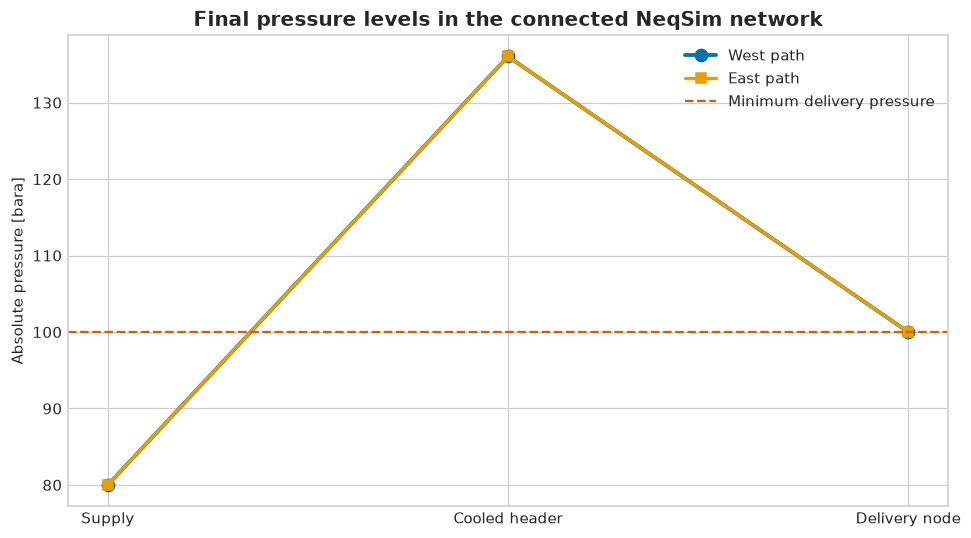

In [26]:
pressure_nodes = [
    SUPPLY_PRESSURE_BARA,
    selected_header_pressure_bara,
    west_pipe.getOutletStream().getPressure("bara"),
]
node_positions = [0.0, 1.0, 2.0]

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.plot(
    node_positions,
    pressure_nodes,
    marker="o",
    markersize=8,
    linewidth=2.5,
    color=COLORS["blue"],
    label="West path",
)
ax.plot(
    node_positions,
    [
        SUPPLY_PRESSURE_BARA,
        selected_header_pressure_bara,
        east_pipe.getOutletStream().getPressure("bara"),
    ],
    marker="s",
    markersize=7,
    linewidth=2.2,
    color=COLORS["orange"],
    label="East path",
)
ax.axhline(
    DELIVERY_PRESSURE_BARA,
    color=COLORS["red"],
    linestyle="--",
    label="Minimum delivery pressure",
)
ax.set_xticks(node_positions)
ax.set_xticklabels(
    [
        "Supply",
        "Cooled header",
        "Delivery node",
    ]
)
ax.set_ylabel("Absolute pressure [bara]")
ax.set_title(
    "Final pressure levels in the connected NeqSim network",
    fontsize=13,
    weight="bold",
)
ax.legend()
fig.tight_layout()

The compressor raises pressure, the cooler restores the hydraulic design temperature, and
both branches arrive at the same delivery pressure. Because the mixer receives
pressure-balanced streams, its result represents a realizable common node rather than an
artificial pressure correction.

## 11. Engineering validation

The checks below are release gates for this educational case. They test input
normalization, gas phase, positive and bounded hydraulics, branch pressure balance,
delivery pressure, total and branch mass closure, component preservation, monotonic
sensitivity, and compressor energy closure.

In [27]:
supply_system = supply_stream.getThermoSystem()
compressor_outlet_system = (
    export_compressor.getOutletStream().getThermoSystem()
)
mixed_system = delivery_mixer.getOutletStream().getThermoSystem()

supply_system.init(3)
compressor_outlet_system.init(3)
mixed_system.init(3)

compressor_enthalpy_rise_kw = (
    compressor_outlet_system.getEnthalpy()
    - supply_system.getEnthalpy()
) / 1000.0
compressor_power_kw = export_compressor.getPower("kW")

total_mass_residual_kg_s = (
    delivery_mixer.getOutletStream().getFlowRate("kg/sec")
    - supply_stream.getFlowRate("kg/sec")
)
branch_mass_residual_kg_s = (
    west_pipe.getOutletStream().getFlowRate("kg/sec")
    + east_pipe.getOutletStream().getFlowRate("kg/sec")
    - supply_stream.getFlowRate("kg/sec")
)
pressure_mismatch_bar = abs(
    west_pipe.getOutletStream().getPressure("bara")
    - east_pipe.getOutletStream().getPressure("bara")
)
energy_residual_kw = abs(
    compressor_power_kw - compressor_enthalpy_rise_kw
)

inlet_composition = np.asarray(
    supply_system.getMolarComposition(),
    dtype=float,
)
outlet_composition = np.asarray(
    mixed_system.getMolarComposition(),
    dtype=float,
)
component_residual = float(
    np.max(np.abs(inlet_composition - outlet_composition))
)

In [28]:
validation_checks = {
    "composition sums to one": abs(
        sum(COMPOSITION_MOLE_FRACTION.values()) - 1.0
    ) < 1.0e-12,
    "reference fluid is gas only": (
        reference_gas.getNumberOfPhases() == 1
    ),
    "base pressure drop is positive": (
        base_pipe["outlet_pressure_bara"] < 145.0
    ),
    "base velocity is positive": base_pipe["velocity_m_s"] > 0.0,
    "base Reynolds number is turbulent": (
        base_pipe["reynolds_number"] > 4000.0
    ),
    "capacity rises with diameter": all(
        group["capacity (kg/s)"].is_monotonic_increasing
        for _, group in capacity_table.groupby("branch")
    ),
    "throughput lowers delivery pressure": (
        throughput_table["delivery pressure (bara)"]
        .is_monotonic_decreasing
    ),
    "selected exact header respects limit": (
        selected_header_pressure_bara
        <= MAXIMUM_HEADER_PRESSURE_BARA
    ),
    "delivery requirement is met": (
        delivery_mixer.getOutletStream().getPressure("bara")
        >= DELIVERY_PRESSURE_BARA - 1.0e-4
    ),
    "branch pressures balance": pressure_mismatch_bar < 1.0e-4,
    "total mass closes": abs(total_mass_residual_kg_s) < 1.0e-9,
    "branch mass closes": abs(branch_mass_residual_kg_s) < 1.0e-9,
    "composition is preserved": component_residual < 1.0e-12,
    "compressor energy closes": energy_residual_kw < 1.0e-6,
    "compressor power is positive": compressor_power_kw > 0.0,
    "all final velocities are positive": (
        west_pipe.getVelocity() > 0.0
        and east_pipe.getVelocity() > 0.0
    ),
    "all final velocities are below 20 m/s": (
        west_pipe.getVelocity() < 20.0
        and east_pipe.getVelocity() < 20.0
    ),
}

failed_checks = [
    name
    for name, passed in validation_checks.items()
    if not passed
]
assert not failed_checks, failed_checks

print(
    f"All {len(validation_checks)} engineering checks passed."
)
print(
    "Selected diameters: "
    f"{selected_west_diameter_m:.2f} / "
    f"{selected_east_diameter_m:.2f} m"
)
print(
    f"Exact cooled header: "
    f"{selected_header_pressure_bara:.6f} bara"
)
print(
    f"Delivery pressure: "
    f"{delivery_mixer.getOutletStream().getPressure('bara'):.6f} bara"
)
print(f"Compressor power: {compressor_power_kw / 1000.0:.6f} MW")
print(f"Mass residual: {total_mass_residual_kg_s:.3e} kg/s")
print(f"Component residual: {component_residual:.3e}")
print(f"Energy residual: {energy_residual_kw:.3e} kW")

All 17 engineering checks passed.
Selected diameters: 0.60 / 0.50 m
Exact cooled header: 136.036105 bara
Delivery pressure: 100.000002 bara
Compressor power: 26.881617 MW
Mass residual: 0.000e+00 kg/s
Component residual: 1.110e-16
Energy residual: 0.000e+00 kW


## 12. Troubleshooting and practical limitations

- **NaN or negative outlet pressure:** the requested flow is outside the physical bracket.
  Increase diameter or header pressure before calling it an optimization result.
- **No sign change in the split residual:** widen the split bracket carefully, but first
  confirm that both branches remain physically solvable.
- **Unexpected liquid phase:** inspect the phase envelope and replace the dry-gas model with
  an appropriate thermal or multiphase pipeline model.
- **Different final pressure after adding a compressor:** cool to the temperature assumed by
  the hydraulic screen. Compressor discharge temperature changes gas density.
- **Slow scenario runs:** retain independent cases but reduce coarse screening points; never
  reuse mutable streams across candidate designs.
- **Project design:** add surveyed terrain, ambient heat transfer, fittings, valves,
  compressor maps, availability, line pack, surge, wall-thickness design, integrity limits,
  uncertainty, and calibrated commercial economics.

## 13. Summary

This notebook replaced an empty template with a complete dry-gas network workflow. NeqSim
supplies the real-gas state, transport properties, pipe hydraulics, compressor duty,
aftercooling, splitting, mixing, and process composition. Independent searches balance
branch pressure, map throughput, screen diameters, and reconcile the selected design in
fixed-flow mode.

The result is reusable for early engineering studies, but it remains a steady, horizontal,
single-phase screening model rather than a certified pipeline design.

## 14. Further exercises

1. Replace the synthetic gas with a public composition and repeat the phase check.
2. Add a third branch and solve two independent node-pressure residuals.
3. Remove one branch to quantify N−1 delivery capacity and compressor pressure.
4. Compare SRK and GERG-2008 gas properties at the same states.
5. Add terrain and heat transfer with a distributed NeqSim pipeline model.
6. Replace the pipe-size proxy with documented project CAPEX and electricity assumptions,
   then calculate a true annualized economic optimum.
7. Add compressor curves and verify that every selected point lies inside the operating
   envelope.

## 15. References

- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [NeqSim Python package on PyPI](https://pypi.org/project/neqsim/)
- [NeqSim `AdiabaticPipe` source and API](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/pipeline/AdiabaticPipe.java)
- [NeqSim process simulation guide](https://equinor.github.io/neqsim/process/)

The pressure-squared relationship is used only for physical interpretation. All reported
network values are calculated with the installed NeqSim release.